In [2]:
import numpy as np
import lightcones as lc
import lightcones.linalg as ll
import matplotlib.pyplot as plt
from lightcones.linalg import mv
from lightcones import models
from lightcones.jumps import make_jump
from lightcones.solvers.schrodinger import solve
plt.rcParams['text.usetex'] = True

In [3]:
# this is necessary for multiprocessing with Numpy computations

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

Let us construct the moving frame: 

In [4]:
# chain
n_sites = 100
# on-site energies
es = [1]*n_sites
# hoppings
hs = [0.05]*(n_sites-1)

# time grid
dt = 0.01
nt = 20000

# spread
spread = lc.metric.spread(es, hs, nt, dt)

# rho_plus
rho_plus = lc.metric.rho_plus(spread, dt)

# minimal light cone
rtol = 10**(-4)
ti_arrival, spread_min, U_min, rho_plus_min = lc.frames.minimal_forward(spread, rho_plus, dt, rtol)

# causal diamond frame
cd_dim = 4
spread_cd, U_cd = lc.frames.causal_diamonds.fixed(spread_min, ti_arrival, U_min, rho_plus_min, dt, rtol, cd_dim)

# moving frame
spread_mv, H_mv = lc.frames.causal_diamonds.moving(spread_cd, ti_arrival, U_cd, dt, cd_dim)

In [10]:
import pickle

with open('moving_frame.pkl', 'wb') as f:
    pickle.dump({
        'cd_dim': cd_dim,
        'dt': dt,
        'nt': nt,
        'ti_arrival': ti_arrival,
        'spread_mv': spread_mv,
        'H_mv': H_mv, 
    }, f)

Let us compute jump trajectories in the moving frame:

In [ ]:
class jump_solver:
    def __init__(self, frame_data_path):

        # load the moving frame
        with open(frame_data_path, 'rb') as f:
            data = pickle.load(f)
            self.cd_dim = data['cd_dim']
            self.dt = data['dt']
            self.nt = data['nt']
            self.ti_arrival = data['ti_arrival']
            self.spread_mv = data['spread_mv']
            self.H_mv = data['H_mv'] 

        #print(self.cd_dim, self.dt, self.nt, self.ti_arrival)

        # Time grid
        self.t_max = self.nt * self.dt
        self.t = np.arange(0, self.t_max + self.dt, self.dt)
        self.n_time = self.nt

        #print(self.t_max, self.n_time, self.nt)

        # Construct model
        num_modes = lc.frames.m_in(self.ti_arrival, self.n_time - 1)
        max_num_quanta = 5
        self.model = models.spin_boson(num_modes, max_num_quanta)

        wq = 1.0
        self.Hs = wq * self.model.s_p @ self.model.s_m
        g = 0.05
        self.V = g * self.model.s_m
        self.V_dag = g * self.model.s_p

        # Auxiliaries
        self.Hint = self.model.space.zero_op
        self.Ht = None
        self.m_out_prev = 0

        self.s_z_av = np.zeros(self.n_time, dtype = complex)

    def driving(self, ti):

        return(0.1*np.cos((ti + 0.5)*self.dt))
    
    def generate(self):

        self.m_out_prev = 0

        psi_0 = np.zeros(self.model.dimension, dtype = complex)
        psi_0[0] = 1

        def begin_step(ti, psi):

            m_out, m_in = lc.frames.causal_diamonds.get_inout_range_fixed(self.ti_arrival, ti, self.cd_dim)
        
            # if the number of decoupled modes is changed: we need to make a jump
            if m_out != self.m_out_prev:
                psi[:] = make_jump(psi, self.model.space, self.m_out_prev + 1) # + 1 because the first mode is the qubit
                self.m_out_prev = m_out 
        
            if m_in > 0:
                self.Hint = self.V_dag @ sum(self.spread_mv[m_out : m_in, ti] * self.model.a[m_out : m_in])
                self.Hint = self.Hint + self.Hint.conj().transpose()

            self.Ht = self.Hs + self.model.s_x * self.driving(ti) + self.Hint
            
            Hw = self.model.zero_op
            W = lc.frames.causal_diamonds.get_H(self.ti_arrival, H_mv, ti)
            if not W is None:
                for p in range(m_in - m_out):
                    for q in range(m_in - m_out):
                        Hw += 1j * self.model.a_dag[m_out + q] @ self.model.a[m_out + p] * W[q, p].conj()
            self.Ht = self.Ht + Hw
    
        def apply_h(ti, psi_in, psi_out):
            mv(self.Ht, psi_in, psi_out)

        def eval_o(ti, psi):
            #print(self.s_z_av)
            self.s_z_av[ti] = self.s_z_av[ti] + np.vdot(psi, self.model.s_z @ psi)

        solve(0, self.n_time-1, self.dt, apply_h, psi_0, begin_step = begin_step, eval_o = eval_o)
    

In [47]:
js = jump_solver('./moving_frame.pkl')
js.generate()

In the plot below we see discontinous changes in the qubit observables at the time moments of jumps:

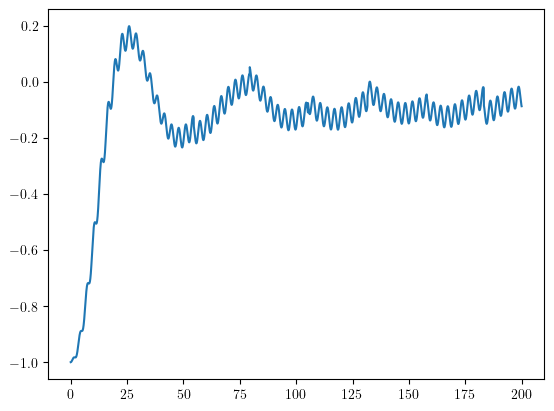

In [48]:
# plot the s_z average 
s_z_av_2 = np.array(js.s_z_av)
plt.plot(js.t[:-1], s_z_av_2.real)
# save picture to file
plt.savefig('s_z_av_spin_boson_model_jumpy.eps', format='eps')

In [ ]:
def job():
    js = jump_solver('./moving_frame.pkl')
    for i in range(10):
        js.generate()
    return js.s_z_av

However the average over many jump trajectories becomes smooth and reproduces the exact quantum dynamics:

In [ ]:
s_z_av_3 = lc.execution.execute(job, 400, 30)

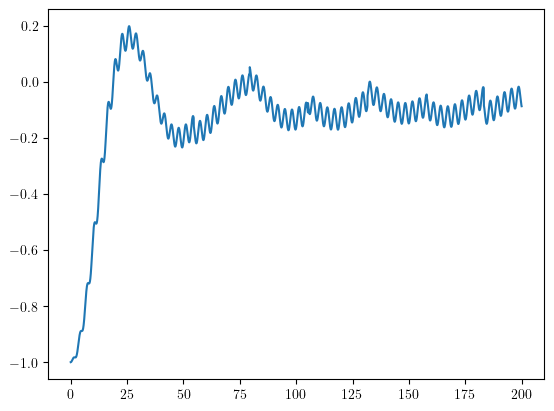

In [ ]:
# plot the s_z average 
plt.plot(t, s_z_av_3.real / 4000)
# save picture to file
plt.savefig('s_z_av_spin_boson_model_jump_average.eps', format='eps')

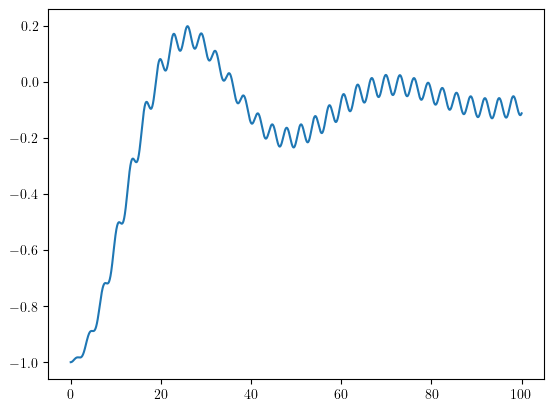

In [20]:
# Let us solve the spin boson model the original (chain sites) picture
# define the Hamiltonian of the spin-boson model

# number of boson chain modes
num_chain_modes = 15

# keep in the truncated Fock space only states in which 
# the bosonic chain has no more than max_num_quanta quanta
max_num_quanta = 5

# sparse matrices for the model
m = models.spin_boson(num_chain_modes, max_num_quanta)

# Hamitonian for the spin (qubit)
# Rabi (level splitting)
Omega = 2.0
Hs = m.s_p @ m.s_m * Omega / 2

# Coupling to the chain via raising / lowering Pauli matrices
# coupling strength g
g = 0.05
V = g * m.s_m @ m.a_dag[0]
V_dag = V.T.conj()

# Free bosonic chain Hamiltonian (on-site energy e and hopping h)
e = 1.0
h = 0.05
Hb = e * sum([m.a_dag[i] @ m.a[i] for i in range(num_chain_modes)]) \
    + h * sum([m.a_dag[i + 1] @ m.a[i] + m.a_dag[i] @ m.a[i + 1] for i in range(num_chain_modes - 1)])
    
# joint Hamiltonian
Hsb = Hs + V + V_dag + Hb

# The qubit is periodically driven
def drive(t):
    return(0.1*np.cos(t)) * m.s_x

# The Hamiltonian for the driven spin-boson model
def Hsb_driven(t):
    return Hsb + drive(t)

# The non-stationary Schrodinger equation is solved on a time grid
# [0    dt    2*dt    ...    k*dt  ... ]
# The time grid points are numbered by integer ti
# [0    1     2       ....   k     ... ]
# The time-dependent Hamiltonian is invoked by the solver with ti argument,
# and the corresponding time moment is (ti + 0.5)*dt
# Here 0.5*dt is due to the midpoint integration rule

# Time step
dt = 0.01

# Final grid
t_max = 100
t = np.arange(0, t_max + dt, dt)
n_time = t.size

# Callback function which applies Hamiltonian to the wavefunction at each time grid point ti
def apply_h(ti, psi_in, psi_out):
    H = Hsb_driven((ti + 0.5) * dt)
    mv(H, psi_in, psi_out, cout=1)

# Here we store the average of observables
s_z_av = []

# Callback function which evaluates observables at each time grid point ti
def eval_o(ti, psi):
    s_z_av.append(np.vdot(psi, m.s_z @ psi))
    
# initial condition:
# vacuum state for bosonic chain,
# and ground state for spin (qubit)
psi_0 = np.zeros(m.dimension, dtype = complex)
psi_0[0] = 1.0 
    
# Solve the non-stationary Schrodinger equation
solve(0, n_time-1, dt, apply_h, psi_0, eval_o = eval_o)

# plot the s_z average 
s_z_av = np.array(s_z_av)
plt.plot(t, s_z_av.real)
# save picture to file
plt.savefig('s_z_av_spin_boson_model.eps', format='eps')

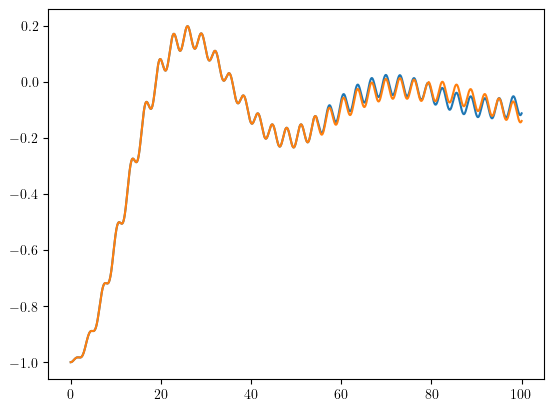

In [27]:
# Compare with the average over the quantum jump trajectories

# plot the s_z average 
plt.plot(t, s_z_av.real)
plt.plot(t, s_z_av_3.real / 100)
# save picture to file
plt.savefig('s_z_av_spin_boson_model_jump_average_compared.eps', format='eps')